# Predictive modelling (RQ2)

**RQ2:** *Can how a country talks about the energy transition at the UN — how often, and how cautiously — predict
the change in its fossil-fuel production over the following year, and is that relationship different for the major
fossil-fuel economies?*

RQ1 (`05_eda_combined`) found that the major fossil-fuel economies that talk more about the transition also cut the
fossil share of their *energy mix* faster. But a country can make its own energy use greener while still producing
and exporting as much as before, so RQ2 turns to **production**, and asks whether the speeches carry *predictive*
information about it.

- **Inputs:** `fossil_fuel_production_by_country_year.csv` (from 03), `speeches_advanced_clean.parquet` (02),
  `speeches_simple_clean.parquet` (01), `major_fossil_economies.csv` (04_eda)
- **Outputs:** `rq2_coefficients.csv` and `rq2_model_comparison.csv` in `datasets/prepared_data/`, and
  `figures/rq2_target_distribution.png`

**Run order:** 01 → 02 → 03 → 04_eda → 05 → this notebook.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = '../datasets/prepared_data'
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42

# Same colours and style as the EDA notebooks
MAJOR_COLOR = '#2a78d6'
INK = '#52514e'
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.titlesize': 10,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'legend.frameon': False,
})

## Step 1 — Target: the change in production over the year after the speech

The General Debate takes place in September. The production change from year *t−1* to year *t* has therefore mostly
happened *before* the speech of year *t* is given, so it cannot be "predicted" by it. We use the change over the
**following** year instead: the speech of year *t* is paired with the relative change in total fossil-fuel production
(coal + oil + gas, in TWh) from year *t* to year *t+1*.

Two details:

- A change is only computed between consecutive years. If a country has a gap in its data, the change across the gap
  is left missing instead of being treated as a one-year change.
- A country going from zero to any production has an infinite relative change; there is no meaningful percentage, so
  that change is dropped.

In [2]:
production = (pd.read_csv(f'{DATA_DIR}/fossil_fuel_production_by_country_year.csv')
              .dropna(subset=['total_production_twh'])
              .sort_values(['iso3', 'Year']))

previous = production.groupby('iso3')['total_production_twh'].shift(1)
consecutive = production.groupby('iso3')['Year'].diff() == 1
production['production_change'] = ((production['total_production_twh'] - previous) / previous).where(consecutive)
production['production_change'] = production['production_change'].replace([np.inf, -np.inf], np.nan)

# The target for the speech of year t is the change from t to t+1, i.e. the next row's change
production['production_change_next'] = production.groupby('iso3')['production_change'].shift(-1)

production.loc[production['Year'] >= 2015, 'production_change_next'].describe().round(3)

count    726.000
mean       0.074
std        2.332
min       -1.000
25%       -0.068
50%       -0.010
75%        0.037
max       62.689
Name: production_change_next, dtype: float64

## Step 2 — Speech features

For every speech since 2015 we use two measures from `02_preprocessing_advanced`:

- **`mentions_per_1k`**: energy-transition mentions per 1,000 words, the same measure as in RQ1. Normalising by
  speech length stops long speeches from looking more engaged just because they are long.
- **`net_caution`**: hedging minus commitment language within ±15 words of each transition mention, divided by the
  number of mentions. It is undefined for speeches without any mention; we set it to 0 (neutral) for those.

We add the **`major_fossil_economy`** flag from `04_eda` (1 for the 15 major fossil-fuel economies, 0 otherwise).

In [3]:
speeches = pd.read_parquet('../datasets/speeches_advanced_clean.parquet')
word_counts = pd.read_parquet('../datasets/speeches_simple_clean.parquet', columns=['WordCount'])
speeches = speeches.join(word_counts, how='left').reset_index().rename(columns={'ISO-alpha3 Code': 'iso3'})

speeches['mentions_per_1k'] = speeches['transition_mention_count'] / speeches['WordCount'] * 1000
speeches['net_caution'] = speeches['word15_net_caution'].fillna(0)

flags = pd.read_csv(f'{DATA_DIR}/major_fossil_economies.csv')
major_iso3 = set(flags.loc[flags['major_fossil_economy'], 'iso3'])
speeches['major_fossil_economy'] = speeches['iso3'].isin(major_iso3).astype(int)

speeches[['mentions_per_1k', 'net_caution']].describe().round(3)

,mentions_per_1k,net_caution
count,2128.000,2128.000
mean,0.334,-0.012
std,0.681,0.126
min,0.000,-2.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.483,0.000
max,7.816,1.000


## Step 3 — Merge speeches with the target

An inner join keeps the country-years that have both a speech and a production change for the following year. OWID
production data covers 73 countries, so the sample is limited to those; the 2025 speeches drop out because the
2025→2026 change is not known yet.

In [4]:
data = (speeches[['iso3', 'Year', 'Country or Area', 'major_fossil_economy', 'mentions_per_1k', 'net_caution']]
        .merge(production[['iso3', 'Year', 'production_change_next']], on=['iso3', 'Year'], how='inner')
        .dropna(subset=['production_change_next'])
        .sort_values(['Year', 'iso3'])
        .reset_index(drop=True))

n_major = data.loc[data['major_fossil_economy'] == 1, 'iso3'].nunique()
print(f"{len(data)} country-years from {data['iso3'].nunique()} countries ({n_major} major fossil-fuel economies), "
      f"speech years {data['Year'].min()}–{data['Year'].max()}")
print(f"Speeches without any transition mention: {(data['mentions_per_1k'] == 0).mean():.0%}")
print(f"Speeches with non-zero net caution:      {(data['net_caution'] != 0).mean():.1%}")

716 country-years from 73 countries (15 major fossil-fuel economies), speech years 2015–2024
Speeches without any transition mention: 72%
Speeches with non-zero net caution:      3.6%


## Step 4 — Chronological train/test split

The data is a panel observed over time, so a random split would let the model learn from years that come *after*
the years it is tested on. We split by speech year instead: the first 80% of the years for training and the last 20%
for testing.

In [5]:
years = sorted(data['Year'].unique())
test_start = years[int(len(years) * 0.8)]
train = data[data['Year'] < test_start].copy()
test = data[data['Year'] >= test_start].copy()

print(f"Train: speech years {train['Year'].min()}–{train['Year'].max()}, {len(train)} rows ({len(train) / len(data):.0%})")
print(f"Test:  speech years {test['Year'].min()}–{test['Year'].max()}, {len(test)} rows ({len(test) / len(data):.0%})")

Train: speech years 2015–2022, 573 rows (80%)
Test:  speech years 2023–2024, 143 rows (20%)


## Step 5 — Winsorise the target

A few country-years have extreme changes, for example a small producer whose output multiplies after a new field
opens. Squared-error models would chase these points. We clip the target at its 1st and 99th percentiles instead of
dropping them. The percentiles are computed on the **training data only** and the same bounds are applied to the test
set, so no information from the test years enters the model.

Bounds from the training data: -0.398 to 0.677
Clipped: 12 training rows, 4 test rows
Training target: median -0.010, share of years with rising production 45%


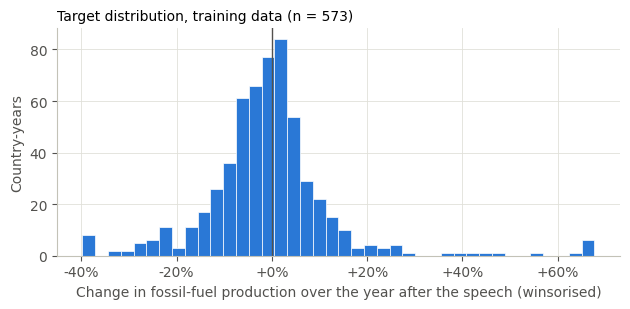

In [6]:
lower, upper = train['production_change_next'].quantile([0.01, 0.99])
for df in (train, test):
    df['target'] = df['production_change_next'].clip(lower, upper)

print(f"Bounds from the training data: {lower:.3f} to {upper:.3f}")
print(f"Clipped: {(train['target'] != train['production_change_next']).sum()} training rows, "
      f"{(test['target'] != test['production_change_next']).sum()} test rows")
print(f"Training target: median {train['target'].median():.3f}, "
      f"share of years with rising production {(train['target'] > 0).mean():.0%}")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(train['target'], bins=40, color=MAJOR_COLOR, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1)
ax.xaxis.set_major_formatter(lambda v, _: f'{v:+.0%}')
ax.set_xlabel('Change in fossil-fuel production over the year after the speech (winsorised)')
ax.set_ylabel('Country-years')
ax.set_title(f'Target distribution, training data (n = {len(train)})', loc='left')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq2_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 6 — Features: centring and interactions

To test whether the relationship differs for the major fossil-fuel economies, we add interaction terms between each
speech measure and the group flag. With interactions, the coefficient of the flag is the difference between the
groups *at a speech-measure value of zero*. We therefore centre both speech measures on their **training** means, so
that this coefficient is the group difference for a speech with average transition talk, which is easier to
interpret. The five features are:

| Feature | Meaning |
|---|---|
| `major_fossil_economy` | group difference at average talk |
| `mentions_per_1k` | effect of transition talk for the other countries |
| `net_caution` | effect of cautious (vs. committal) language for the other countries |
| `mentions_x_major` | how much the talk effect differs for the major fossil-fuel economies |
| `caution_x_major` | how much the caution effect differs for the major fossil-fuel economies |

In [7]:
centre = train[['mentions_per_1k', 'net_caution']].mean()


def build_features(df):
    X = pd.DataFrame(index=df.index)
    X['major_fossil_economy'] = df['major_fossil_economy']
    X['mentions_per_1k'] = df['mentions_per_1k'] - centre['mentions_per_1k']
    X['net_caution'] = df['net_caution'] - centre['net_caution']
    X['mentions_x_major'] = X['mentions_per_1k'] * X['major_fossil_economy']
    X['caution_x_major'] = X['net_caution'] * X['major_fossil_economy']
    return X


X_train, X_test = build_features(train), build_features(test)
y_train, y_test = train['target'], test['target']
print(f"Training means used for centring: mentions_per_1k = {centre['mentions_per_1k']:.3f}, "
      f"net_caution = {centre['net_caution']:.4f}")

Training means used for centring: mentions_per_1k = 0.246, net_caution = -0.0136


## Step 7 — Inference: OLS coefficients and their standard errors

We first fit an ordinary least squares (OLS) model on the training data, to see whether any coefficient is
distinguishable from zero. Plain OLS standard errors assume that the errors have constant variance and are
independent. We check both assumptions:

- **Constant variance:** a Breusch–Pagan test. If it rejects, heteroskedasticity-consistent (HC3) standard errors
  are needed.
- **Independence:** the data contains the same countries every year, so errors of one country are likely correlated
  over time. **Country-clustered** standard errors allow for that, and are the most appropriate here; HC3 and plain
  standard errors are shown for comparison.

The residuals are also strongly non-normal (see skew and kurtosis in the summary). With several hundred observations,
inference on the coefficients relies on large-sample approximations rather than on normality.

In [8]:
X_train_c = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_c).fit()
ols_hc3 = sm.OLS(y_train, X_train_c).fit(cov_type='HC3')
ols_cluster = sm.OLS(y_train, X_train_c).fit(cov_type='cluster', cov_kwds={'groups': train['iso3']})

print(ols.summary())

bp_lm, bp_p, _, _ = het_breuschpagan(ols.resid, X_train_c)
print(f"\nBreusch–Pagan test: LM = {bp_lm:.2f}, p = {bp_p:.4f}")
print(f"Overall F-test p-value: classic {ols.f_pvalue:.3f}, HC3 {ols_hc3.f_pvalue:.3f}, "
      f"clustered {ols_cluster.f_pvalue:.3f}")

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9870
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.425
Time:                        01:47:58   Log-Likelihood:                 328.19
No. Observations:                 573   AIC:                            -644.4
Df Residuals:                     567   BIC:                            -618.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.0135 

In [9]:
coef_table = pd.DataFrame({
    'coef': ols.params,
    'se_classic': ols.bse, 'p_classic': ols.pvalues,
    'se_hc3': ols_hc3.bse, 'p_hc3': ols_hc3.pvalues,
    'se_cluster': ols_cluster.bse, 'p_cluster': ols_cluster.pvalues,
})
print(f"n = {int(ols.nobs)}, training R² = {ols.rsquared:.3f}, adjusted R² = {ols.rsquared_adj:.3f}, "
      f"countries (clusters) = {train['iso3'].nunique()}")
coef_table.round(4)

n = 573, training R² = 0.009, adjusted R² = -0.000, countries (clusters) = 73


,coef,se_classic,p_classic,se_hc3,p_hc3,se_cluster,p_cluster
const,-0.0135,0.0065,0.0364,0.0072,0.0590,0.0104,0.1943
major_fossil_economy,0.0218,0.0142,0.1249,0.0089,0.0142,0.0114,0.0561
mentions_per_1k,-0.0129,0.0111,0.2428,0.0175,0.4592,0.0173,0.4554
net_caution,0.0652,0.0765,0.3940,0.0824,0.4286,0.0669,0.3293
mentions_x_major,0.0161,0.0221,0.4673,0.0191,0.3996,0.0195,0.4098
caution_x_major,-0.0819,0.1082,0.4496,0.0855,0.3383,0.0674,0.2241


The central question for RQ2 is whether the four speech terms *together* add anything, beyond the group flag. We
test that jointly (Wald test that all four speech coefficients are zero) under each type of standard error.

In [10]:
speech_terms = ['mentions_per_1k', 'net_caution', 'mentions_x_major', 'caution_x_major']
hypothesis = ', '.join(f'{term} = 0' for term in speech_terms)
for label, result in [('classic', ols), ('HC3', ols_hc3), ('clustered', ols_cluster)]:
    joint = result.f_test(hypothesis)
    print(f"All four speech terms = 0 ({label:9s} SEs): F = {np.squeeze(joint.fvalue):.2f}, "
          f"p = {np.squeeze(joint.pvalue):.3f}")

All four speech terms = 0 (classic   SEs): F = 0.64, p = 0.637
All four speech terms = 0 (HC3       SEs): F = 0.60, p = 0.665
All four speech terms = 0 (clustered SEs): F = 2.06, p = 0.095


## Step 8 — Prediction: model comparison

To answer the *predictive* part of RQ2 we compare models on how well they predict production changes in years they
have not seen:

- **Baseline:** always predicts the training mean. Any useful model has to beat this.
- **Linear regression, group flag only:** uses only `major_fossil_economy`. Comparing it with the full linear model
  shows whether the speech features add anything beyond knowing which group a country belongs to.
- **Linear regression:** all five features (the same model as in Step 7).
- **Ridge regression:** linear regression with a penalty that shrinks coefficients, which can help when the signal is
  weak and noisy. Features are standardised first, and the penalty strength `alpha` is tuned.
- **Random forest:** a non-linear model that can pick up thresholds and interactions the linear models miss. Tree
  depth and minimum leaf size are tuned.

**Model selection** uses only the training years, with time-ordered cross-validation: `TimeSeriesSplit` over the
eight training years gives four folds, each training on all earlier years and validating on the next one (validation
years 2019–2022). The model with the lowest cross-validated RMSE is selected; the test set is used only once, to
evaluate.

In [11]:
train_years = np.array(sorted(train['Year'].unique()))
row_years = train['Year'].to_numpy()
cv_folds = []
for fit_idx, val_idx in TimeSeriesSplit(n_splits=4).split(train_years):
    cv_folds.append((np.flatnonzero(np.isin(row_years, train_years[fit_idx])),
                     np.flatnonzero(np.isin(row_years, train_years[val_idx]))))
    print(f"Fold {len(cv_folds)}: train on {train_years[fit_idx].min()}–{train_years[fit_idx].max()}, "
          f"validate on {train_years[val_idx].min()}")

Fold 1: train on 2015–2018, validate on 2019
Fold 2: train on 2015–2019, validate on 2020
Fold 3: train on 2015–2020, validate on 2021
Fold 4: train on 2015–2021, validate on 2022


In [12]:
ALL_FEATURES = list(X_train.columns)
candidates = {
    'Baseline (training mean)': (DummyRegressor(strategy='mean'), {}, ALL_FEATURES),
    'Linear regression, group flag only': (LinearRegression(), {}, ['major_fossil_economy']),
    'Linear regression': (LinearRegression(), {}, ALL_FEATURES),
    'Ridge regression': (make_pipeline(StandardScaler(), Ridge()),
                         {'ridge__alpha': np.logspace(-2, 4, 13)}, ALL_FEATURES),
    'Random forest': (RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
                      {'max_depth': [2, 3, 5], 'min_samples_leaf': [5, 10, 20]}, ALL_FEATURES),
}

rows = []
for name, (model, grid, features) in candidates.items():
    search = GridSearchCV(model, grid, cv=cv_folds, scoring='neg_root_mean_squared_error')
    search.fit(X_train[features], y_train)
    pred = search.best_estimator_.predict(X_test[features])
    rows.append({
        'model': name,
        'tuned_parameters': ', '.join(f'{k.split("__")[-1]}={v:g}' if isinstance(v, float) else f'{k}={v}'
                                      for k, v in search.best_params_.items()) or '-',
        'cv_rmse': -search.best_score_,
        'test_rmse': root_mean_squared_error(y_test, pred),
        'test_mae': mean_absolute_error(y_test, pred),
        'test_r2': r2_score(y_test, pred),
    })

comparison = pd.DataFrame(rows).set_index('model')
selected = comparison['cv_rmse'].idxmin()
print(f"Selected by cross-validated RMSE: {selected}")
comparison.round(4)

Selected by cross-validated RMSE: Linear regression, group flag only


,tuned_parameters,cv_rmse,test_rmse,test_mae,test_r2
model,,,,,
Baseline (training mean),-,0.1477,0.1387,0.0883,-0.0058
"Linear regression, group flag only",-,0.1475,0.1380,0.0877,0.0034
Linear regression,-,0.1532,0.1417,0.0898,-0.0500
Ridge regression,alpha=10000,0.1478,0.1387,0.0883,-0.0066
Random forest,"max_depth=5, min_samples_leaf=20",0.1491,0.1384,0.0879,-0.0024


## Step 9 — Results

**Inference (Step 7).**
- The Breusch–Pagan test rejects constant variance (LM = 11.50, p = 0.042), so the plain OLS standard errors are not
  reliable. We rely on the country-clustered ones, which also allow for correlation within a country over time.
- **None of the four speech terms is significant** under any type of standard error: every p-value is above 0.2.
  Jointly, the four speech terms are not significant either (p = 0.64 classic, 0.67 HC3, 0.095 clustered).
- In particular, the interaction terms show **no evidence that the relationship differs** for the major fossil-fuel
  economies.
- The only term close to significance is the group flag. At average transition talk, the major fossil-fuel
  economies' production grew about 2.2 percentage points per year faster than the other countries'. This is weak
  evidence: p = 0.056 with clustered errors, and the conclusion depends on the type of standard error (0.125 classic,
  0.014 HC3).
- The model explains almost nothing of the variation in the target (training R² = 0.009).

**Prediction (Step 8).**
- No model predicts the next year's production change meaningfully better than always predicting the training mean.
  Cross-validation selects the linear model with only the group flag (CV RMSE 0.1475 vs. 0.1477 for the baseline).
  On the test years (2023–2024) it improves the RMSE by less than 1% (0.1380 vs. 0.1387; test R² = 0.003).
- Adding the speech features makes out-of-sample predictions *worse*: the full linear model has test RMSE 0.1417 and
  R² = −0.05, i.e. it fits noise.
- Ridge picks the largest penalty in its grid (alpha = 10,000), which shrinks all coefficients to almost zero and
  reproduces the baseline.
- The random forest, which could find non-linear patterns, does no better (test RMSE 0.1384).

**Answer to RQ2.** How often and how cautiously a country talks about the energy transition at the UN does **not**
predict how its fossil-fuel production changes over the following year, and there is no sign that this is different
for the major fossil-fuel economies. Together with RQ1, this suggests that transition talk goes together with changes
in a country's own *energy mix*, but not with how much fossil fuel it *produces*.

**Caveats.**
- One-year production changes are driven mostly by prices, OPEC+ quotas, the 2020 pandemic and the 2022 energy
  crisis, which speeches cannot capture. A longer horizon might show more.
- The speech features are sparse: 72% of speeches never mention the transition, and only 3.6% have non-zero net
  caution. That limits the power to detect a weak effect.
- The sample covers only the 73 countries in the OWID production data, and the test period is only two years
  (143 country-years).

## Step 10 — Save

The coefficient table and the model comparison are saved so the report can use them without re-running this
notebook.

In [13]:
coef_table.to_csv(f'{DATA_DIR}/rq2_coefficients.csv', index_label='term')
comparison.to_csv(f'{DATA_DIR}/rq2_model_comparison.csv')
print(coef_table.shape, comparison.shape)

(6, 7) (5, 5)
